EDA QUESTIONS
1. What time periods have the highest transaction amounts?
2. What locations are more likely to habor fraudulent transactions? And what are the average transaction amounts in those locations?
3. Do higher transaction amounts indicate fraud?
4. Which transaction type has more fraudulent transactions? 
5. Which merchant values have the highest fraud rate? And where are they located?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
credit_fraud = pd.read_csv('../data/credit_card_fraud_dataset.csv')
credit_fraud.head()

,TransactionID,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud
0,1,2024-04-03 14:15:35.462794,4189.27,688,refund,San Antonio,0
1,2,2024-03-19 13:20:35.462824,2659.71,109,refund,Dallas,0
2,3,2024-01-08 10:08:35.462834,784.00,394,purchase,New York,0
3,4,2024-04-13 23:50:35.462850,3514.40,944,purchase,Philadelphia,0
4,5,2024-07-12 18:51:35.462858,369.07,475,purchase,Phoenix,0


NUMBER OF FRAUD VS NON-FRAUD TRANSACTIONS

In [3]:
credit_fraud["IsFraud"].value_counts()

IsFraud
0    99000
1     1000
Name: count, dtype: int64

In [6]:
credit_fraud["IsFraud"].value_counts(normalize=True)*100

IsFraud
0    99.0
1     1.0
Name: proportion, dtype: float64

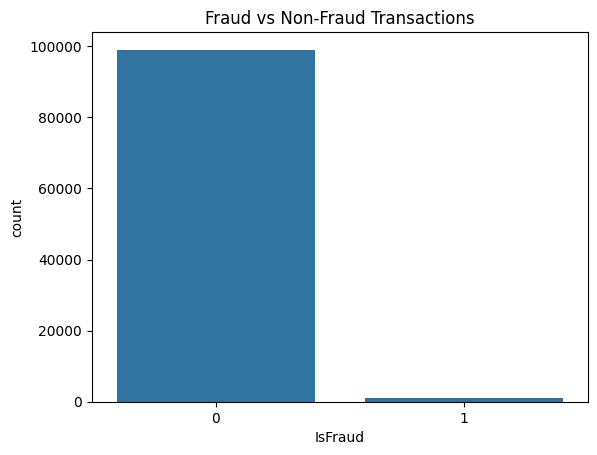

In [7]:
sns.countplot(x="IsFraud", data=credit_fraud)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

QUESTION 1

In [9]:
credit_fraud = pd.read_csv("../data/credit_card_fraud_dataset.csv", parse_dates=["TransactionDate"])
credit_fraud["Hour"] = credit_fraud["TransactionDate"].dt.hour
credit_fraud["DayOfWeek"] = credit_fraud["TransactionDate"].dt.day_name()
credit_fraud["Month"] = credit_fraud["TransactionDate"].dt.month_name()
credit_fraud["Year"] = credit_fraud["TransactionDate"].dt.year
credit_fraud.head()

,TransactionID,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud,Hour,DayOfWeek,Month,Year
0,1,2024-04-03 14:15:35.462794,4189.27,688,refund,San Antonio,0,14,Wednesday,April,2024
1,2,2024-03-19 13:20:35.462824,2659.71,109,refund,Dallas,0,13,Tuesday,March,2024
2,3,2024-01-08 10:08:35.462834,784.00,394,purchase,New York,0,10,Monday,January,2024
3,4,2024-04-13 23:50:35.462850,3514.40,944,purchase,Philadelphia,0,23,Saturday,April,2024
4,5,2024-07-12 18:51:35.462858,369.07,475,purchase,Phoenix,0,18,Friday,July,2024


C:\Users\USER\AppData\Local\Temp\ipykernel_5912\3471801869.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


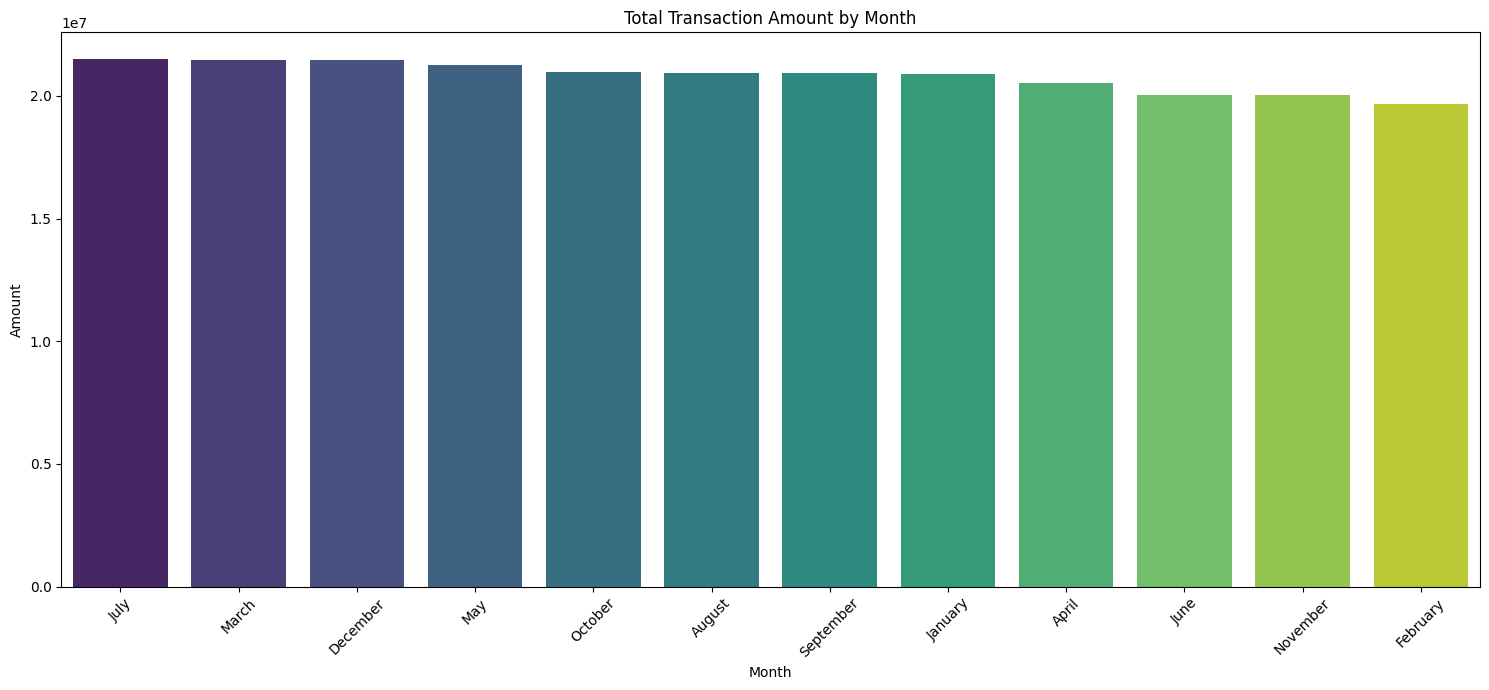

In [18]:
plt.figure(figsize=(15, 7))
sns.barplot(
    data=credit_fraud.groupby("Month")["Amount"].sum().reset_index().sort_values("Amount", ascending=False),
    x="Month",
    y="Amount",
    palette="viridis"
)
plt.title("Total Transaction Amount by Month")
plt.xticks(rotation=45)
plt.tight_layout()

C:\Users\USER\AppData\Local\Temp\ipykernel_5912\1675598672.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\USER\AppData\Local\Temp\ipykernel_5912\1675598672.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
C:\Users\USER\AppData\Local\Temp\ipykernel_5912\1675598672.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


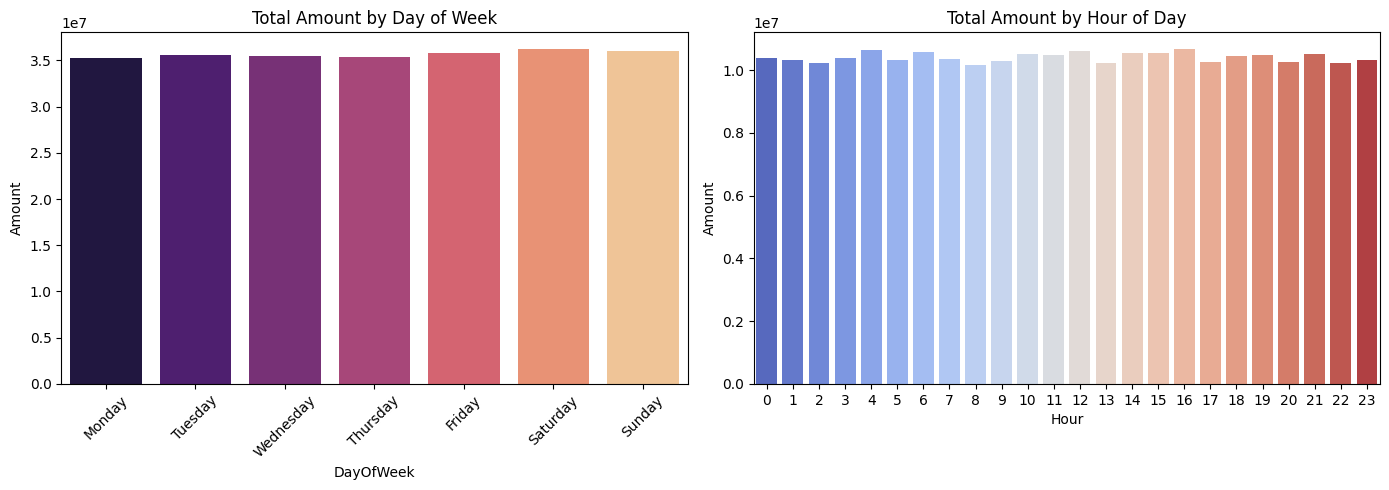

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

sns.barplot(
    data=credit_fraud.groupby("DayOfWeek")["Amount"].sum().reindex(
        ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
    ).reset_index(),
    x="DayOfWeek",
    y="Amount",
    ax=axes[0],
    palette="magma"
)
axes[0].set_title("Total Amount by Day of Week")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)

sns.barplot(
    data=credit_fraud.groupby("Hour")["Amount"].sum().reset_index(),
    x="Hour",
    y="Amount",
    ax=axes[1],
    palette="coolwarm"
)
axes[1].set_title("Total Amount by Hour of Day")

plt.tight_layout()

QUESTION 2

In [46]:
location_stats = (
    credit_fraud.groupby("Location")
      .agg(
          fraud_count=("IsFraud", "sum"),
          total_transactions=("IsFraud", "count"),
          fraud_rate=("IsFraud", "mean"),
          avg_amount=("Amount", "mean")
      )
      .sort_values("fraud_rate", ascending=False)
      .reset_index()
)

location_stats.head(10)

,Location,fraud_count,total_transactions,fraud_rate,avg_amount
0,New York,116,9993,0.011608,2491.948727
1,San Diego,115,10111,0.011374,2489.408425
2,Houston,105,9991,0.010509,2510.600224
3,Phoenix,99,9960,0.009940,2509.400378
4,San Antonio,99,10062,0.009839,2484.659923
5,Dallas,99,10076,0.009825,2492.671768
6,Los Angeles,95,9936,0.009561,2493.017409
7,Chicago,95,10193,0.009320,2497.522896
8,Philadelphia,90,9873,0.009116,2496.504547
9,San Jose,87,9805,0.008873,2505.569568


C:\Users\USER\AppData\Local\Temp\ipykernel_5912\3137501637.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


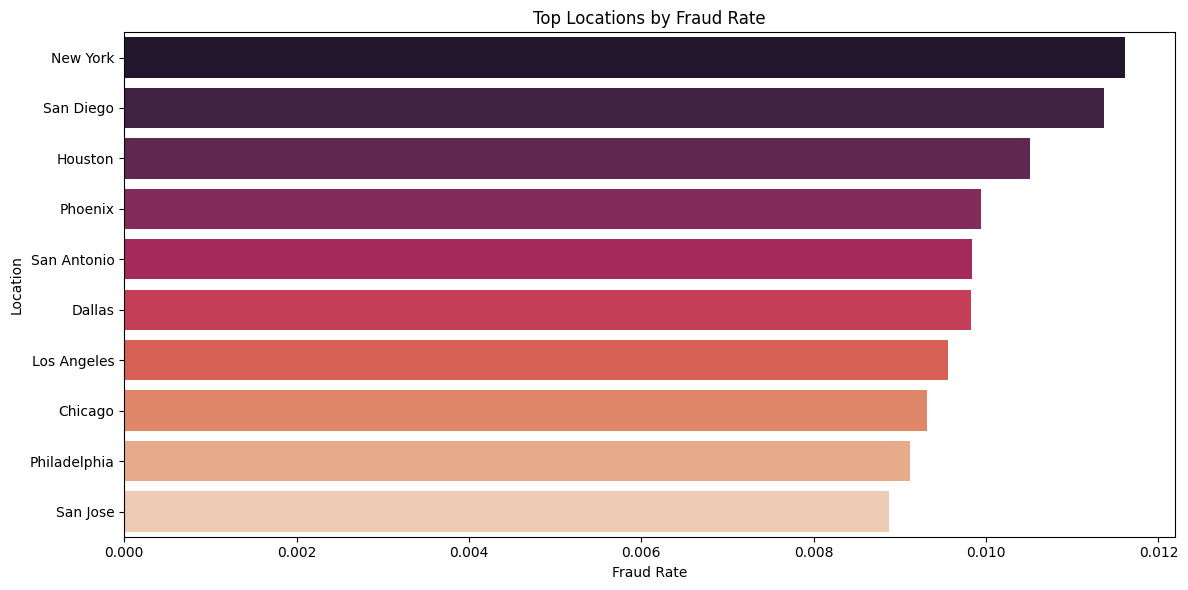

In [47]:
fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=location_stats.sort_values("fraud_rate", ascending=False).head(12),
    x="fraud_rate",
    y="Location",
    ax=ax1,
    palette="rocket"
)
ax1.set_xlabel("Fraud Rate")
ax1.set_title("Top Locations by Fraud Rate")
plt.tight_layout()

QUESION 3

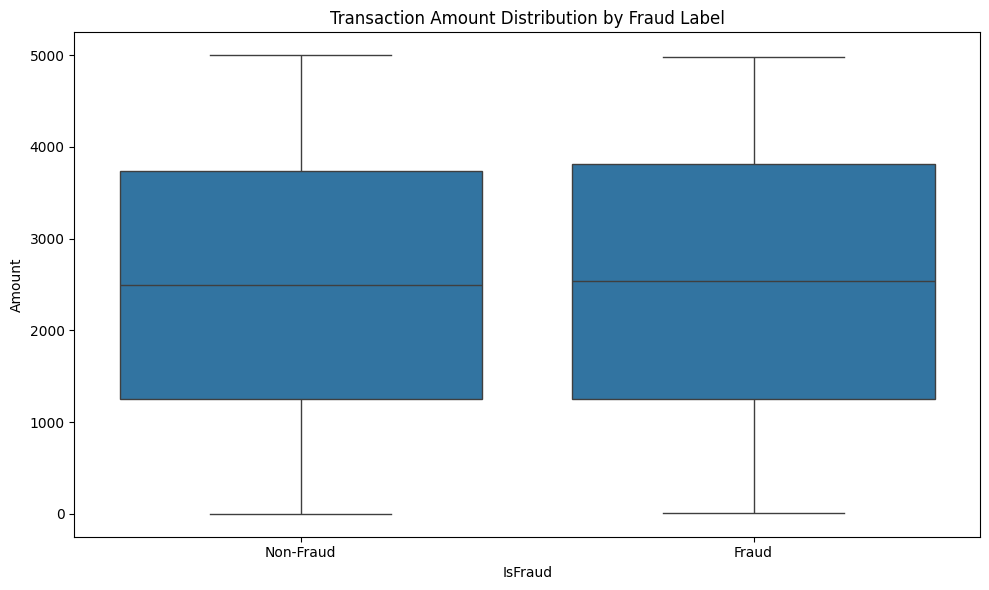

In [29]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=credit_fraud, x="IsFraud", y="Amount")
plt.xticks([0, 1], ["Non-Fraud", "Fraud"])
plt.title("Transaction Amount Distribution by Fraud Label")
plt.tight_layout()

QUESTION 4

In [34]:
type_stats = (
    credit_fraud.groupby("TransactionType")
      .agg(fraud_count=("IsFraud", "sum"), total=("IsFraud", "count"))
      .assign(fraud_rate=lambda x: x["fraud_count"] / x["total"])
      .reset_index()
)

type_stats

,TransactionType,fraud_count,total,fraud_rate
0,purchase,493,49869,0.009886
1,refund,507,50131,0.010114


C:\Users\USER\AppData\Local\Temp\ipykernel_5912\1751392745.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


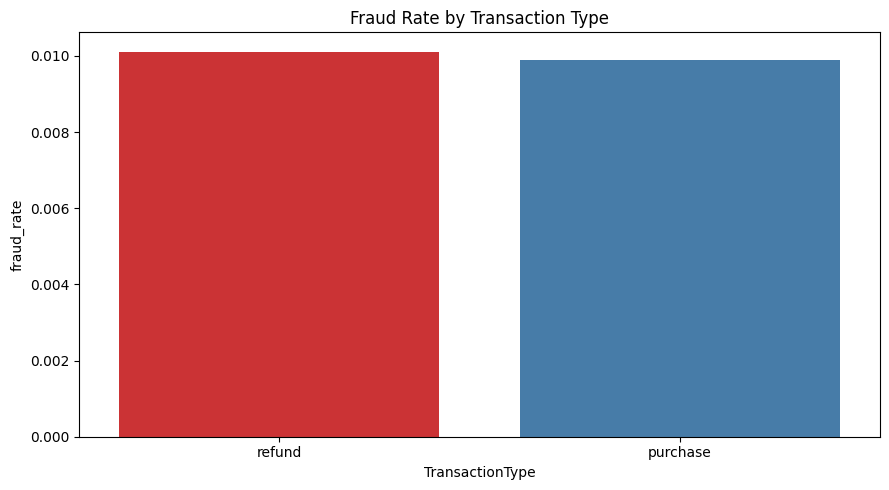

In [36]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=type_stats.sort_values("fraud_rate", ascending=False),
    x="TransactionType",
    y="fraud_rate",
    palette="Set1"
)
plt.title("Fraud Rate by Transaction Type")
plt.tight_layout()

QUESTION 5

In [39]:
merchant_stats = (
    credit_fraud.groupby(["MerchantID", "Location"])
      .agg(
          fraud_count=("IsFraud", "sum"),
          total_transactions=("IsFraud", "count"),
          fraud_rate=("IsFraud", "mean"),
          avg_amount=("Amount", "mean")
      )
      .query("total_transactions >= 10")
      .sort_values("fraud_rate", ascending=False)
      .reset_index()
)

merchant_stats.head(20)

,MerchantID,Location,fraud_count,total_transactions,fraud_rate,avg_amount
0,112,Los Angeles,2,10,0.200000,2347.140000
1,959,Dallas,2,10,0.200000,2455.875000
2,216,New York,3,15,0.200000,2967.963333
3,204,San Diego,2,10,0.200000,2763.066000
4,837,Chicago,2,10,0.200000,1534.901000
5,6,Los Angeles,2,10,0.200000,2092.723000
6,659,Houston,4,21,0.190476,2734.133810
7,176,Dallas,2,11,0.181818,2767.465455
8,306,Los Angeles,2,11,0.181818,3168.837273
9,346,Dallas,2,11,0.181818,2754.482727


C:\Users\USER\AppData\Local\Temp\ipykernel_5912\3820617177.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


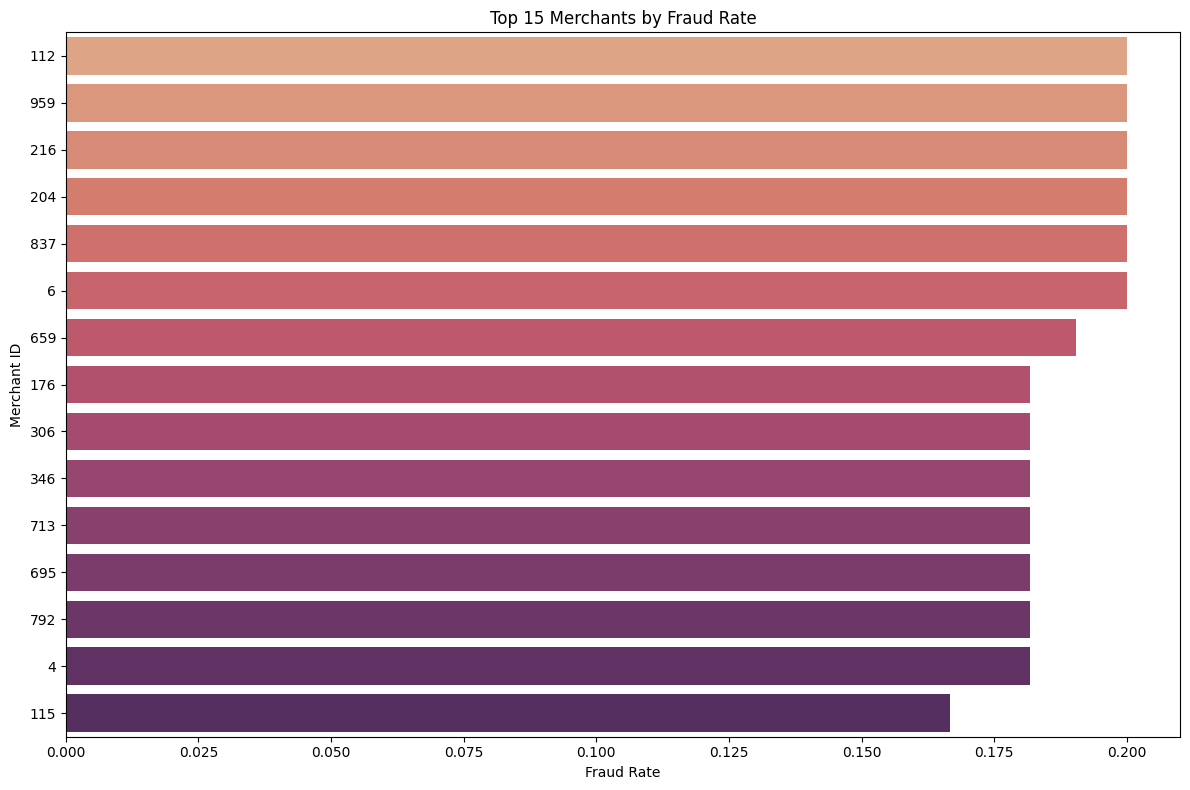

In [44]:
plt.figure(figsize=(12, 8))
sns.barplot(
    data=merchant_stats.head(15),
    x="fraud_rate",
    y=merchant_stats.head(15)["MerchantID"].astype(str),
    palette="flare"
)
plt.xlabel("Fraud Rate")
plt.ylabel("Merchant ID")
plt.title("Top 15 Merchants by Fraud Rate")
plt.tight_layout()